In [1]:
r0 = 0.0001

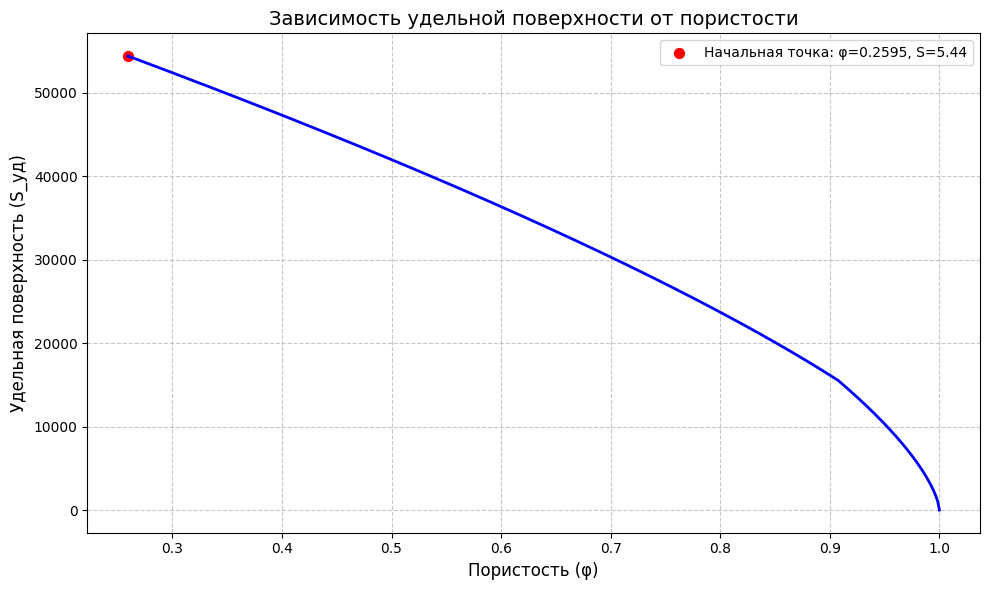

In [2]:
import math
import numpy as np
import matplotlib.pyplot as plt

# Исходные константы
phi_sh0 = math.pi / (3 * math.sqrt(2))  # ≈0.7405
phi_por0 = 1 - phi_sh0                  # ≈0.2595

# Теоретическое значение удельной поверхности при начальной пористости
S_ud_initial_theory = 5.44
# Расчетное значение по модели при начальной пористости
S_ud_initial_model = (3 * phi_sh0 * math.pi * 3.5) / 4  # ≈6.115
# Поправочный коэффициент
scale = S_ud_initial_theory / S_ud_initial_model

def area_sphere_surface(porosity, R0=1.0):
    """
    Вычисляет удельную поверхность пористого материала.
    
    Параметры:
        porosity (float): Пористость материала (от 0.2595 до 1).
        R0 (float): Начальный радиус шаров (по умолчанию 1.0).
        
    Возвращает:
        float: Удельная поверхность (единицы: 1/ед. длины).
    """
    if porosity >= 1.0:
        return 0.0
    if porosity <= phi_por0:
        x = 1.0
    else:
        phi_sh = 1 - porosity
        x = (phi_sh / phi_sh0) ** (1/3)
    
    K0 = (3 * phi_sh0 * math.pi) / 4
    
    if x > 0.5:
        S_ud_R0 = K0 * (4 * x**2 - x + 0.5)
    else:
        S_ud_R0 = 4 * K0 * x**2
    
    S_ud_R0_corrected = scale * S_ud_R0
    return S_ud_R0_corrected / R0

# Создание данных для графика
porosities = np.linspace(phi_por0, 1, 500)
areas = [area_sphere_surface(p, R0=r0) for p in porosities]

# Построение графика
plt.figure(figsize=(10, 6))
plt.plot(porosities, areas, color='b', linewidth=2)
plt.scatter(phi_por0, area_sphere_surface(phi_por0, R0=r0), color='r', s=50, label=f'Начальная точка: φ={phi_por0:.4f}, S={area_sphere_surface(phi_por0):.2f}')
plt.title('Зависимость удельной поверхности от пористости', fontsize=14)
plt.xlabel('Пористость (φ)', fontsize=12)
plt.ylabel('Удельная поверхность (S_уд)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()


$$S_{\text{уд}} = \frac{3 \cdot (1 - \text{porosity})}{R_0 \cdot \phi_{\text{sh0}}^{1/3}} \cdot (1 - \text{porosity})^{2/3}$$

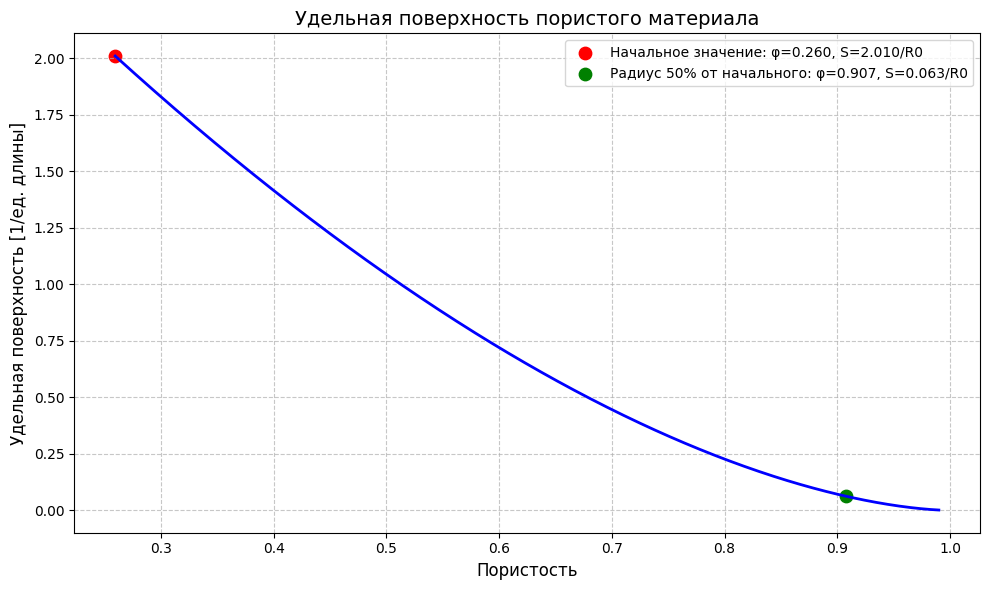

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import math

# Константы
phi_sh0 = math.pi / (3 * math.sqrt(2))  # ≈0.7405 (начальная объемная доля шаров)
phi_por0 = 1 - phi_sh0  # ≈0.2595 (начальная пористость)

def area_sphere_surface(porosity, R0=1.0):
    """
    Вычисляет удельную поверхность пористого материала, состоящего из шаров,
    при равномерном растворении шаров и фиксированных центрах.
    
    Параметры:
        porosity (float или np.ndarray): пористость материала (от 0.2595 до 1)
        R0 (float): начальный радиус шаров (по умолчанию 1.0)
        
    Возвращает:
        float или np.ndarray: удельная поверхность [ед. площади/ед. объема]
    """
    # Объемная доля шаров
    phi_sh = 1 - porosity
    
    # Удельная поверхность
    S_ud = (3 * phi_sh) / (R0 * phi_sh0**(1/3)) * phi_sh**(2/3)
    
    # Обработка граничных значений
    if isinstance(porosity, np.ndarray):
        S_ud[porosity < phi_por0] = np.nan
        S_ud[porosity > 1] = np.nan
    else:
        if porosity < phi_por0 or porosity > 1:
            return np.nan
            
    return S_ud

# Создаем диапазон пористости
porosity_range = np.linspace(phi_por0, 0.99, 500)

# Рассчитываем удельную поверхность
surface_area = area_sphere_surface(porosity_range)

# Построение графика
plt.figure(figsize=(10, 6))
plt.plot(porosity_range, surface_area, 'b-', linewidth=2)
plt.title('Удельная поверхность пористого материала', fontsize=14)
plt.xlabel('Пористость', fontsize=12)
plt.ylabel('Удельная поверхность [1/ед. длины]', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

# Отмечаем начальную точку
initial_surface = area_sphere_surface(phi_por0)
plt.scatter([phi_por0], [initial_surface], color='red', s=80, 
            label=f'Начальное значение: φ={phi_por0:.3f}, S={initial_surface:.3f}/R0')

# Отмечаем точку, когда шары уменьшаются вдвое
half_radius_porosity = 1 - phi_sh0 * (0.5)**3
half_radius_surface = area_sphere_surface(half_radius_porosity)
plt.scatter([half_radius_porosity], [half_radius_surface], color='green', s=80, 
            label=f'Радиус 50% от начального: φ={half_radius_porosity:.3f}, S={half_radius_surface:.3f}/R0')

plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

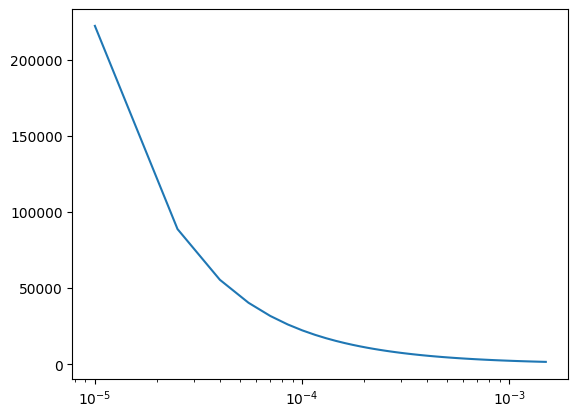

In [4]:
x = np.linspace(0.00001, 0.0015, 100, endpoint=True)
plt.plot(x, np.sqrt(2) * np.pi / 2 / x)
plt.xscale("log")

In [5]:
porosity_range

array([0.25951951, 0.2609834 , 0.26244729, 0.26391118, 0.26537507,
       0.26683895, 0.26830284, 0.26976673, 0.27123062, 0.27269451,
       0.2741584 , 0.27562229, 0.27708618, 0.27855006, 0.28001395,
       0.28147784, 0.28294173, 0.28440562, 0.28586951, 0.2873334 ,
       0.28879729, 0.29026117, 0.29172506, 0.29318895, 0.29465284,
       0.29611673, 0.29758062, 0.29904451, 0.3005084 , 0.30197228,
       0.30343617, 0.30490006, 0.30636395, 0.30782784, 0.30929173,
       0.31075562, 0.31221951, 0.31368339, 0.31514728, 0.31661117,
       0.31807506, 0.31953895, 0.32100284, 0.32246673, 0.32393062,
       0.3253945 , 0.32685839, 0.32832228, 0.32978617, 0.33125006,
       0.33271395, 0.33417784, 0.33564173, 0.33710561, 0.3385695 ,
       0.34003339, 0.34149728, 0.34296117, 0.34442506, 0.34588895,
       0.34735284, 0.34881672, 0.35028061, 0.3517445 , 0.35320839,
       0.35467228, 0.35613617, 0.35760006, 0.35906395, 0.36052783,
       0.36199172, 0.36345561, 0.3649195 , 0.36638339, 0.36784

In [6]:
def perm(perm0, phi, phi0, beta):
    return perm0 * phi / phi0 * np.power(phi * (1 - phi0) / phi0 / (1-phi), 2*beta)

def rad(rad0, perm, perm0, phi0, phi):
    return rad0 * np.sqrt(perm * phi0 / perm0 / phi)

def area(area0, phi, phi0, rad0, rad):
    return area0 * phi / phi0 * rad0 / rad

def cozeny_carman_area(phi, phi0, init_area, beta):
    return init_area * phi / phi0 * np.power((phi0 * (1 - phi)) / (phi * (1 - phi0)), beta)

In [7]:
def perm_fict_grunt_studfile(phi, c, av):
    # https://studfile.net/preview/9742864/page:6/
    return phi**3 / c / av

In [8]:
r0 = 0.0001

In [9]:
init_perm = perm_fict_grunt_studfile(phi_por0, 5, np.power(1 - porosity_range, 2/3) * np.power(9 * np.pi, 1/3) / r0)[0]
init_perm

1.4019531282041707e-07

In [10]:
def my_area_func(phi, r0):
    return np.power(1 - phi, 2/3) * np.power(9 * np.pi, 1/3) / r0

In [11]:
init_area = my_area_func(porosity_range, r0)[0]
init_area

24934.837415820017

In [12]:
beta = 0.85
rad0 = 0.0001
# cozeny_carman_area = area(init_area, porosity_range, phi_por0, rad0, rad(rad0, perm(init_perm, porosity_range, phi_por0, beta), init_perm, phi_por0, porosity_range))

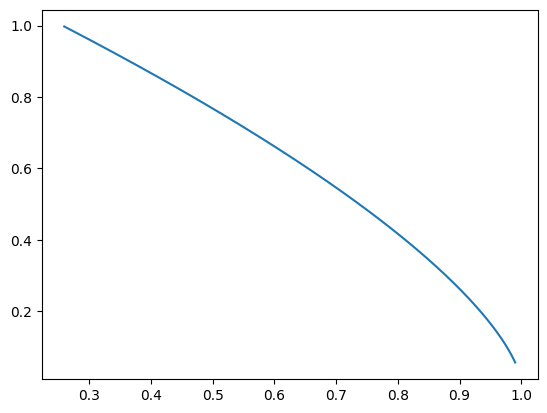

In [13]:
plt.plot(porosity_range, my_area_func(porosity_range, r0) / 25000)
# plt.plot(porosity_range, cozeny_carman_area / 25000)
# plt.plot(porosity_range, np.power(porosity_range, 3) / 5 / (np.power(1 - porosity_range, 2/3) * np.power(9 * np.pi, 1/3) / r0) / 0.00014)
plt.show()

In [14]:
porosity_range = np.linspace(0.00001, 1.0, 1000, endpoint=True)
surface_area = my_area_func(porosity_range, r0)

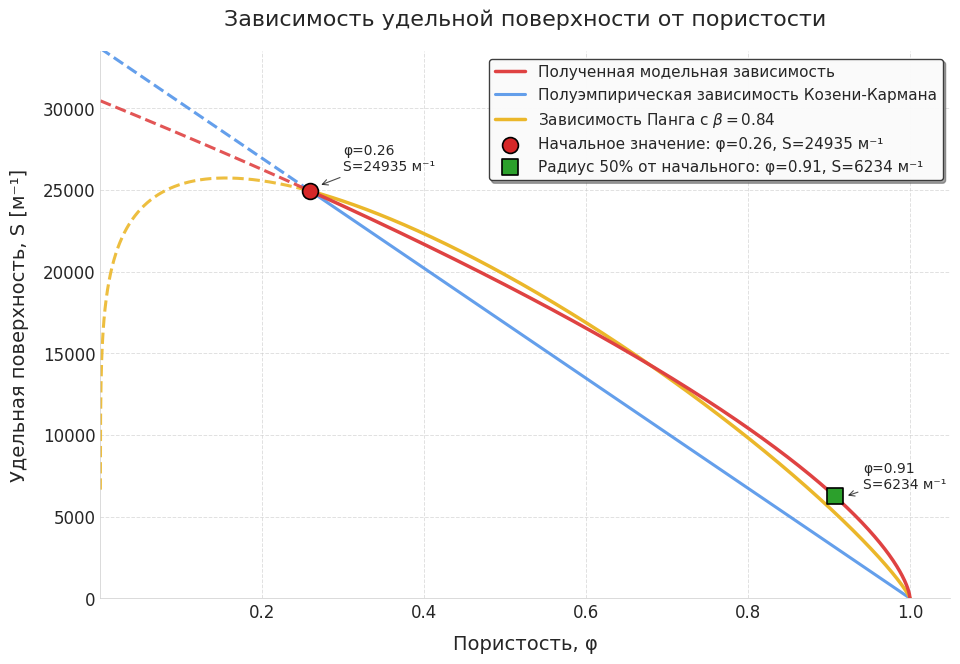

In [27]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib as mpl

# Настройка стиля для научных публикаций
plt.style.use('seaborn-v0_8-whitegrid')
mpl.rcParams['font.family'] = 'DejaVu Sans'
mpl.rcParams['axes.labelsize'] = 14
mpl.rcParams['xtick.labelsize'] = 12
mpl.rcParams['ytick.labelsize'] = 12
mpl.rcParams['legend.fontsize'] = 11
mpl.rcParams['axes.titlepad'] = 18  # Больший отступ для заголовка

# Цветовая схема для научной графики
MODEL_COLOR = "#df4242"  # Основная синяя модель
KOZENY_COLOR = "#3d87e7"  # Серый для Козени-Кармана (более насыщенный)
MODERN_COLOR = "#ebb72a"  # Розово-фиолетовый вместо оранжевого
POINT_COLOR1 = '#d62728'  # Красный для начальной точки
POINT_COLOR2 = '#2ca02c'  # Зеленый для второй точки

initial_surface = my_area_func(phi_por0, r0)

# Создание фигуры с улучшенными параметрами
fig, ax = plt.subplots(figsize=(10, 7), dpi=100)

# Улучшенные линии с разными стилями пунктира
x = np.linspace(0.00001, phi_por0, 1000, endpoint=True)
y = np.linspace(phi_por0, 1.0, 1000, endpoint=True)

# Основная модельная зависимость
ax.plot(x, my_area_func(x, r0), '--', color=MODEL_COLOR, linewidth=2.2, alpha=0.9, zorder=2)
ax.plot(y, my_area_func(y, r0), '-', color=MODEL_COLOR, linewidth=2.5, alpha=1, zorder=2,
        label='Полученная модельная зависимость')

# Зависимость Козени-Кармана
ax.plot(x, cozeny_carman_area(x, phi_por0, initial_surface, 1), '--', 
        color=KOZENY_COLOR, linewidth=2.2, alpha=0.8, zorder=1)
ax.plot(y, cozeny_carman_area(y, phi_por0, initial_surface, 1), '-', 
        color=KOZENY_COLOR, linewidth=2.2, alpha=0.8, zorder=1,
        label='Полуэмпирическая зависимость Козени-Кармана')

# Модернизированная зависимость
ax.plot(x, cozeny_carman_area(x, phi_por0, initial_surface, 0.845), '--', 
        color=MODERN_COLOR, linewidth=2.2, alpha=0.9, zorder=1)
ax.plot(y, cozeny_carman_area(y, phi_por0, initial_surface, 0.845), '-', 
        color=MODERN_COLOR, linewidth=2.5, alpha=1, zorder=1,
        label=r'Зависимость Панга с $\beta=0.84$')



# Настройка осей и заголовка
ax.set_title('Зависимость удельной поверхности от пористости', fontsize=16)
ax.set_xlabel('Пористость, φ', fontsize=14, labelpad=10)
ax.set_ylabel('Удельная поверхность, S [м⁻¹]', fontsize=14, labelpad=10)

# Настройка сетки
ax.grid(True, linestyle='--', linewidth=0.7, alpha=0.6)

# Точки с улучшенной визуализацией
ax.scatter([phi_por0], [initial_surface], 
           color=POINT_COLOR1, s=130, 
           edgecolor='black', linewidth=1.2,
           zorder=4, marker='o', 
           label=f'Начальное значение: φ={phi_por0:.2f}, S={initial_surface:.0f} м⁻¹')

half_radius_porosity = 1 - np.pi / (3 * np.sqrt(2)) * (r0/2)**3 / (r0**3)
half_radius_surface = my_area_func(half_radius_porosity, r0)
ax.scatter([half_radius_porosity], [half_radius_surface], 
           color=POINT_COLOR2, s=130, 
           edgecolor='black', linewidth=1.2,
           zorder=4, marker='s', 
           label=f'Радиус 50% от начального: φ={half_radius_porosity:.2f}, S={half_radius_surface:.0f} м⁻¹')

# Добавление подписей к точкам
ax.annotate(f'φ={phi_por0:.2f}\nS={initial_surface:.0f} м⁻¹', 
            xy=(phi_por0+0.01, initial_surface*1.013), 
            xytext=(phi_por0+0.04, initial_surface*1.05),
            arrowprops=dict(arrowstyle='->', color='black', alpha=0.7, linewidth=0.8),
            fontsize=10, zorder=5)

ax.annotate(f'φ={half_radius_porosity:.2f}\nS={half_radius_surface:.0f} м⁻¹', 
            xy=(half_radius_porosity+0.0125, half_radius_surface), 
            xytext=(half_radius_porosity+0.035, half_radius_surface*1.08),
            arrowprops=dict(arrowstyle='->', color='black', alpha=0.7, linewidth=0.8),
            fontsize=10, zorder=5)

# Легенда с улучшенным оформлением
legend = ax.legend(loc='best', frameon=True, framealpha=0.95, 
                  shadow=True, fancybox=True)
legend.get_frame().set_edgecolor('#333333')  # Темная рамка для контраста

# Настройка пределов осей
ax.set_xlim(min(porosity_range)*0.95, max(porosity_range)*1.05)
ax.set_ylim(min(surface_area)*0.9, max(surface_area)*1.1)

# Добавление научного стиля
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(0.5)
ax.spines['bottom'].set_linewidth(0.5)
ax.tick_params(axis='both', which='major', width=0.8)

# Оптимизация компоновки
plt.tight_layout(pad=2.0)

# Сохранение в высоком качестве
plt.savefig('surface_area_vs_porosity.png', dpi=300, bbox_inches='tight', 
           facecolor='white', transparent=False)
plt.show()

In [16]:
half_radius_porosity

0.9074399387883674

In [17]:
half_radius_surface

6233.709353955006